# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [4]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [6]:
# mostrar las primeras 5 filas de plans
display(plans.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:
# mostrar las primeras 5 filas de users
display(users.head())


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:
# mostrar las primeras 5 filas de usage
display(usage.head())

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:
# inspección de plans con .info()
plans_meta = pd.DataFrame({
    'Tipo de Dato': plans.dtypes,
    'Valores No Nulos': plans.notna().sum(),
    'Valores Nulos': plans.isna().sum()
})
plans_meta

,Tipo de Dato,Valores No Nulos,Valores Nulos
plan_name,object,2,0
messages_included,int64,2,0
gb_per_month,int64,2,0
minutes_included,int64,2,0
usd_monthly_pay,int64,2,0
usd_per_gb,float64,2,0
usd_per_message,float64,2,0
usd_per_minute,float64,2,0


In [11]:
# inspección de users con .info()

users_meta = pd.DataFrame({
    'Tipo de Dato': users.dtypes,
    'Valores No Nulos': users.notna().sum(),
    'Valores Nulos': users.isna().sum()
})
users_meta

,Tipo de Dato,Valores No Nulos,Valores Nulos
user_id,int64,4000,0
first_name,object,4000,0
last_name,object,4000,0
age,int64,4000,0
city,object,3531,469
reg_date,object,4000,0
plan,object,4000,0
churn_date,object,466,3534


In [12]:
# inspección de usage con .info()
usage_meta = pd.DataFrame({
    'Tipo de Dato': usage.dtypes,
    'Valores No Nulos': usage.notna().sum(),
    'Valores Nulos': usage.isna().sum()
})
usage_meta

,Tipo de Dato,Valores No Nulos,Valores Nulos
id,int64,40000,0
user_id,int64,40000,0
type,object,40000,0
date,object,39950,50
duration,float64,17924,22076
length,float64,22104,17896


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [17]:
# cantidad de nulos para users
print # Cantidad de valores nulos)
print # Proporción de valores nulos)
nulos_users_cantidad = users.isna().sum()
nulos_users_proporcion = users.isna().mean()

df_nulos_users = pd.DataFrame({
    'Cantidad Nulos': nulos_users_cantidad,
    'Proporción Nulos': nulos_users_proporcion})
df_nulos_users

,Cantidad Nulos,Proporción Nulos
user_id,0,0.00000
first_name,0,0.00000
last_name,0,0.00000
age,0,0.00000
city,469,0.11725
reg_date,0,0.00000
plan,0,0.00000
churn_date,3534,0.88350


In [21]:
# cantidad de nulos para usage
nulos_usage_cantidad = usage.isna().sum()
nulos_usage_proporcion = usage.isna().mean()

df_nulos_usage = pd.DataFrame({
    'Cantidad Nulos': nulos_usage_cantidad,
    'Proporción Nulos': nulos_usage_proporcion})
df_nulos_usage



,Cantidad Nulos,Proporción Nulos
id,0,0.00000
user_id,0,0.00000
type,0,0.00000
date,50,0.00125
duration,22076,0.55190
length,17896,0.44740


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Explicación:
churn_date (en users): Hay 3,534 valores nulos (88.35%). Decisión: Mantenerlos como nulos porque indican que el usuario sigue activo con la empresa.

city (en users): Hay 469 valores nulos (11.72%). Decisión: Imputarlos con un valor genérico como "Desconocido" porque representa un porcentaje manejable y nos evita perder esos registros al agrupar.

date (en usage): Hay 50 valores nulos (0.12%). Decisión: Eliminar esas filas o marcarlas como nulas; es menos del 1% del dataset, por lo que el impacto es nulo.

duration y length (en usage): Tienen 22,076 (55.19%) y 17,896 (44.74%) valores nulos respectivamente. Decisión: Mantenerlos así porque son nulos lógicos (MAR) según el tipo de consumo (los textos no duran minutos; las llamadas no consumen megabytes).

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [22]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- Es una secuencia numérica consecutiva sin valores duplicados que identifica correctamente a cada uno de los 4,000 usuarios. No presenta anomalías.
- La columna `age` ...Presenta un valor mínimo de -999, lo cual es un evidente valor sentinel (error de captura o dato faltante). El resto de la distribución (con una media de alrededor de 45 años y un máximo de 75) parece completamente normal.

In [23]:
# explorar columnas numéricas de usage
usage[['duration', 'length']].describe()

,duration,length
count,17924.000000,22104.000000
mean,5.202237,52.127398
std,6.842701,56.611183
min,0.000000,0.000000
25%,1.437500,37.000000
50%,3.500000,50.000000
75%,6.990000,64.000000
max,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas d y user_id: Son identificadores clave que ligan el consumo con la transacción y el cliente. Sus rangos mínimos y máximos son lógicos y consistentes con los IDs de la tabla de usuarios.

Las columnas duration y length: Muestran distribuciones consistentes para sus consumos reales (minutos de llamada y megabytes de datos). No se observan valores negativos ni valores fuera de la escala lógica del negocio.

In [25]:
# explorar columnas categóricas de users
{col: users[col].unique() for col in columnas_user}

{'city': array(['Medellín', '?', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
       dtype=object),
 'plan': array(['Basico', 'Premium'], dtype=object)}

- La columna `city` Contiene nombres de ciudades de Latinoamérica, pero presenta el valor "?" como un string único. Este carácter actúa como un valor sentinel para denotar registros donde no se capturó la procedencia del usuario
- La columna `plan` Cuenta únicamente con dos valores únicos bien definidos (los nombres de los planes de ConnectaTel), sin errores ortográficos ni categorías inconsistentes.

In [26]:
# explorar columna categórica de usage
usage['type'] .value_counts().to_frame()

,type
text,22092
call,17908


- La columna `type`:Contiene únicamente las categorías 'call' (llamadas) y 'text' (mensajes de texto). No hay strings vacíos ni categorías adicionales inconsistentes.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

 Valores inválidos o sentinels

¿En qué columnas encontraste valores inválidos o sentinels?

En la columna age (del dataset users) se detectó el valor sentinel -999.

En la columna city (del dataset users) se detectó el valor sentinel "?".

¿Qué acción tomarías?

Para age: Reemplazar el valor -999 por la mediana de la edad de los usuarios (calculada excluyendo el sentinel), ya que la mediana es robusta ante valores extremos.

Para city: Reemplazar el carácter "?" con un valor nulo oficial de pandas (pd.NA) para que no se contabilice como una ciudad real durante las agrupaciones.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [27]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [28]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [29]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().to_frame()

,reg_date
2024,1330
2023,1316
2022,1314
2026,40


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

Vemos registros de los años 2024 (1,330), 2023 (1,316) y 2022 (1,314). ¡Todos estos son correctos y lógicos!

Sin embargo, aparecen 40 registros con el año 2026. Dado que las instrucciones indican que el límite de captura de los datos es hasta el año 2024, estas 40 fechas del año 2026 representan fechas imposibles (un error de captura o datos futuros).

In [30]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().to_frame()

,date
2024.0,39950


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

El 100% de los registros válidos (39,950 consumos) pertenecen estrictamente al año 2024. Aquí no hay fechas imposibles ni años fuera de rango.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Fechas fuera de rango

¿Aparecen años imposibles?

En reg_date (de users): Sí, se detectaron 40 registros con el año 2026, lo cual es imposible ya que la base de datos solo llega de forma válida hasta 2024.

En date (de usage): No, todos los registros de consumo con fecha pertenecen de forma consistente al año 2024 (39,950 registros).

¿Qué harías con ellas?

Para esos 40 registros de reg_date en 2026, los marcaremos como nulos (pd.NaT). Esto nos permite proteger la integridad de nuestros cálculos de antigüedad sin necesidad de eliminar por completo la información de consumo de esos 40 usuarios.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [31]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [32]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isna().sum()

565

In [34]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).to_frame()

,reg_date
2024.0,1330
2023.0,1316
2022.0,1314
NaN,40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [35]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()).to_frame()

,duration
type,
call,0.000000
text,0.999276


In [36]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean()).to_frame()

,length
type,
call,0.99933
text,0.00000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Diagnóstico de nulos en duration y length

Tras agrupar por la columna type, observe que la ausencia de datos es de tipo MAR (Missing At Random) debido a la lógica del negocio:

En duration: El 99.93% de los registros de tipo 'text' son nulos. Esto es correcto porque los mensajes de texto no acumulan minutos de duración.

En length: El 99.93% de los registros de tipo 'call' son nulos. Esto es consistente ya que las llamadas de voz tradicionales no consumen datos de internet.

Decisión: Mantenerlos como nulos. No se deben imputar, ya que mantenerlos como nulos preserva la distinción física entre lo que es un mensaje de texto y lo que es una llamada dentro del análisis de consumo.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [37]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [38]:
# Renombrar columnas
users_merged = users.merge(usage_agg, on='user_id', how='left')

columnas_consumo = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
users_merged[columnas_consumo] = users_merged[columnas_consumo].fillna(0)
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [39]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

columnas_consumo = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_consumo] = user_profile[columnas_consumo].fillna(0)

user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [43]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [41]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True).to_frame()

,plan
Basico,0.64875
Premium,0.35125


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

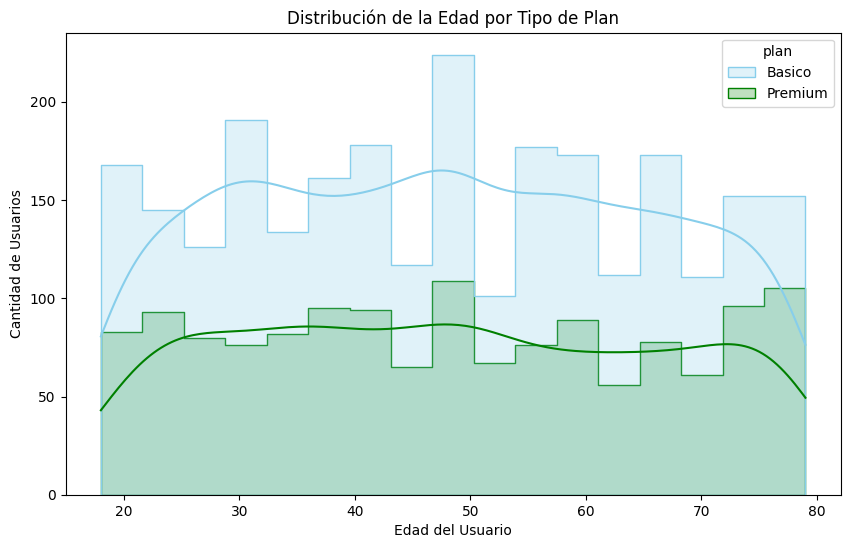

In [44]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', element="step", palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de la Edad por Tipo de Plan')
plt.xlabel('Edad del Usuario')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución: Uniforme (aproximadamente simétrica y plana). La edad de los usuarios se distribuye de manera muy constante y homogénea entre los 18 y los 80 años, sin mostrar un pico pronunciado en ninguna edad en particular ni sesgos hacia los jóvenes o adultos mayores.

Comportamiento por plan: No existe un patrón o preferencia de plan por edad. Tanto los usuarios jóvenes como los mayores eligen el plan Básico o el Premium en proporciones muy similares. El plan Básico es simplemente el más popular de manera uniforme en todos los rangos de edad.

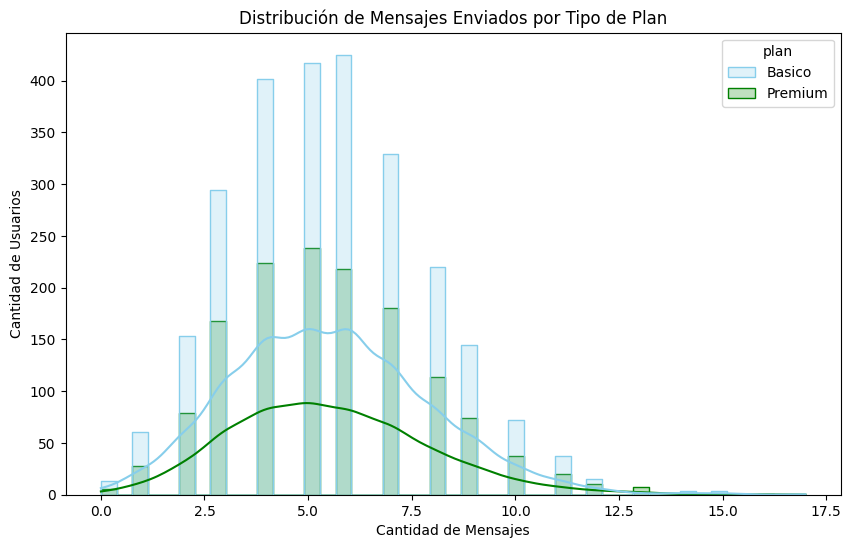

In [45]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', element="step", palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución: Aproximadamente Normal y Simétrica. Ambas distribuciones (Básico en azul y Premium en verde) muestran una forma de campana centrada alrededor de los 5 mensajes. No presentan un sesgo pronunciado hacia ninguno de los extremos.

Comportamiento por plan: No existe un patrón o diferencia clara en el volumen de mensajes. El rango y el promedio de mensajes enviados por los usuarios del plan Básico y Premium son casi idénticos (concentrándose la mayoría entre 2.5 y 7.5 mensajes). La mayor altura de las barras azules simplemente refleja que hay más usuarios en el plan Básico, no que envíen más mensajes.

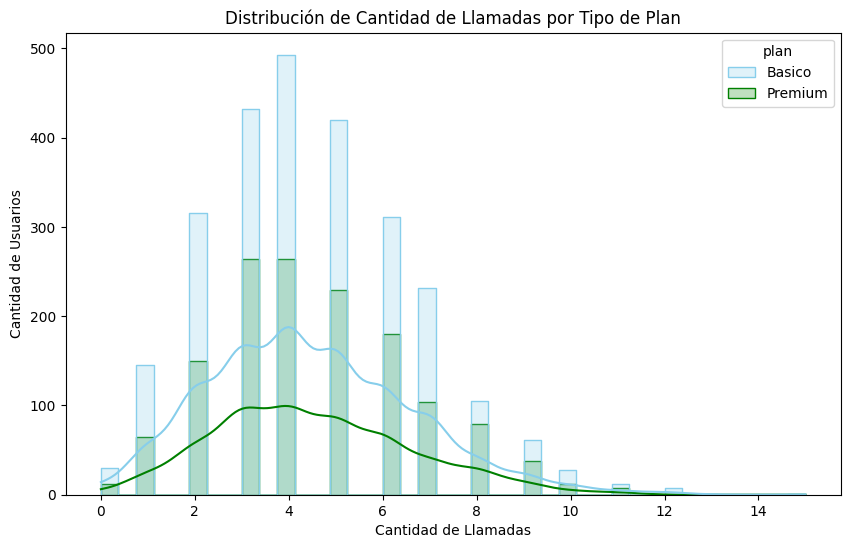

In [46]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', element="step", palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 

- Distribución: Ligeramente sesgada a la derecha. Aunque tiene una forma acampanada similar a una distribución normal, presenta una cola más larga hacia el lado derecho (usuarios que realizan de 8 a 14 llamadas). El pico de llamadas de la gran mayoría de los clientes se concentra en 4 llamadas.

Comportamiento por plan: No existe un patrón diferenciado por tipo de plan. Tanto los usuarios con plan Básico como los del plan Premium muestran exactamente la misma tendencia y volumen en su cantidad de llamadas diarias o mensuales. Al igual que con los mensajes, las barras del plan Básico son más altas debido a que el volumen total de usuarios en este plan es mayor, no porque realicen más llamadas de forma individual.

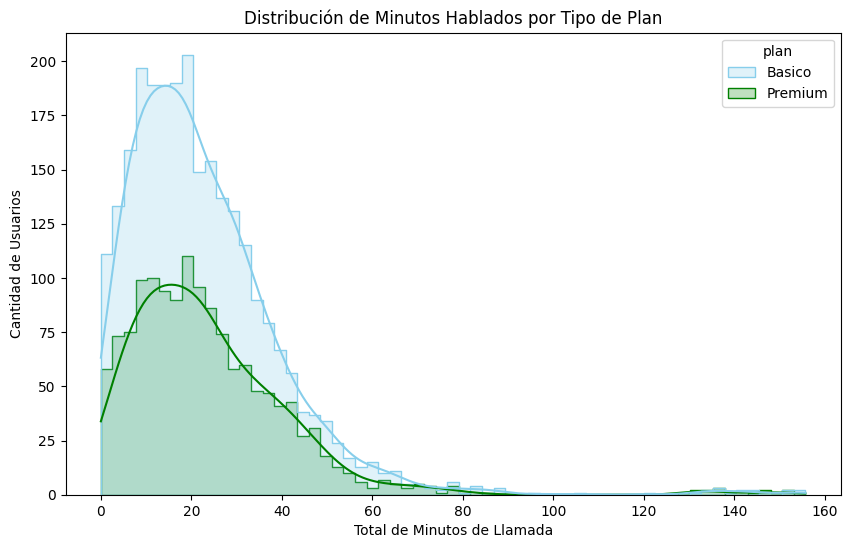

In [47]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', element="step", palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Minutos Hablados por Tipo de Plan')
plt.xlabel('Total de Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
- Distribución: Sesgada a la derecha. Ambas curvas muestran una clara inclinación, donde la mayor concentración de usuarios se agrupa en consumos bajos y medios, con un pico de usuarios acumulado entre los 10 y 25 minutos hablados. A partir de ahí, la distribución se extiende con una cola larga hacia el extremo derecho (usuarios que hablan más de 60 minutos).

Comportamiento por plan: Las tendencias de consumo de minutos son muy homogéneas entre ambos planes. A pesar de que el plan Premium ofrece (teóricamente) mayores beneficios, el comportamiento de consumo de minutos de sus usuarios replica de forma casi idéntica la curva de distribución de los clientes del plan Básico. No se observa que los usuarios Premium hablen significativamente más tiempo que los del plan Básico en su comportamiento histórico.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

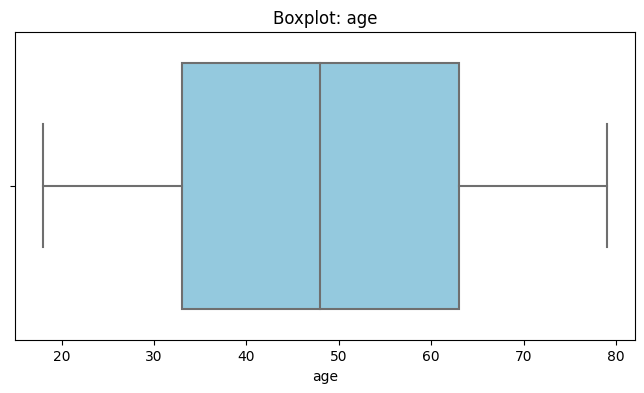

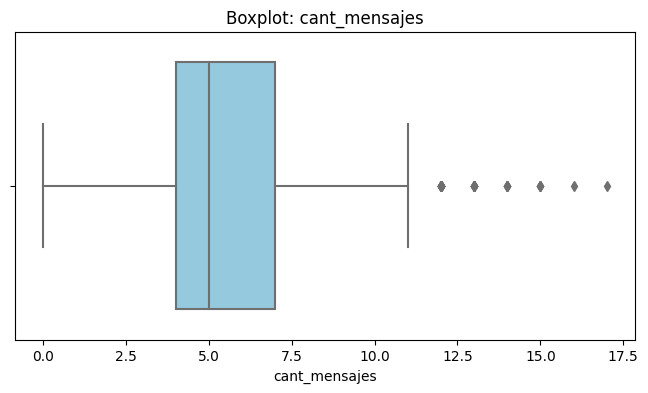

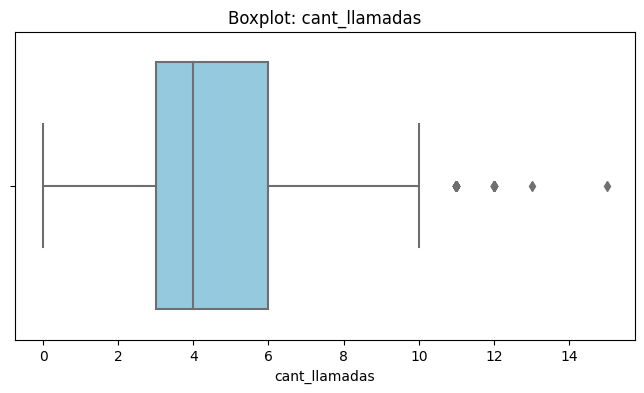

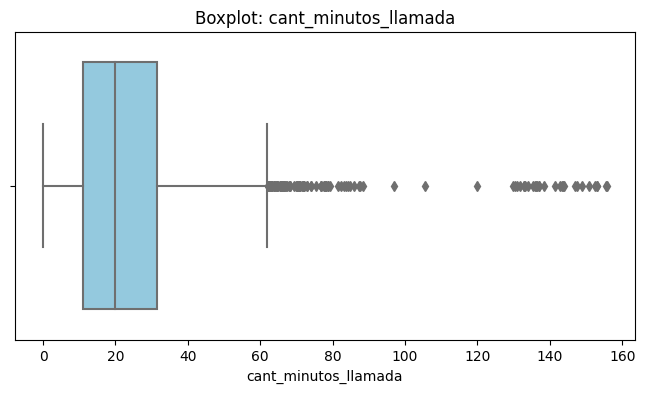

In [48]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No presenta outliers. La variable está perfectamente distribuida y contenida dentro de los límites esperados (los bigotes van desde los 18 hasta los 80 años de edad de forma simétrica).

-cant_mensajes: Presenta outliers en el extremo derecho. Existen valores atípicos a partir de 11 mensajes. Son pocos usuarios, pero hay registros de personas que envían hasta 17 mensajes de forma atípica.

-cant_llamadas: Presenta outliers en el extremo derecho. Los valores atípicos comienzan a partir de las 10 llamadas. Se observan puntos aislados de usuarios que realizan 11, 12, 13 y hasta 15 llamadas.

-cant_minutos_llamada: Presenta una alta cantidad de outliers en el extremo derecho. Los valores atípicos comienzan a partir de los 62 minutos aproximadamente, extendiéndose en una larga fila de puntos individuales que llega hasta casi los 160 minutos. Esto nos indica claramente la presencia de un grupo importante de heavy users (usuarios de alto consumo de tiempo).

In [53]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + (1.5 * IQR)
    outliers_count = (user_profile[col] > limite_superior).sum()
    
    print(f"Variable: {col}")
    print(f"  - Q1: {Q1:.2f}")
    print(f"  - Q3: {Q3:.2f}")
    print(f"  - IQR: {IQR:.2f}")
    print(f"  - Limite Superior: {limite_superior:.2f}")
    print(f"  - Cantidad de outliers: {outliers_count}")
    print("-" * 40)

Variable: cant_mensajes
  - Q1: 4.00
  - Q3: 7.00
  - IQR: 3.00
  - Limite Superior: 11.50
  - Cantidad de outliers: 46
----------------------------------------
Variable: cant_llamadas
  - Q1: 3.00
  - Q3: 6.00
  - IQR: 3.00
  - Limite Superior: 10.50
  - Cantidad de outliers: 30
----------------------------------------
Variable: cant_minutos_llamada
  - Q1: 11.11
  - Q3: 31.41
  - IQR: 20.30
  - Limite Superior: 61.87
  - Cantidad de outliers: 109
----------------------------------------


In [54]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

-Mantener todos los valores atípicos (outliers) en el dataset sin modificarlos ni eliminarlos.

Justificación basada en los datos:

Al analizar el resumen estadístico, vemos que los valores máximos alcanzados son lógicos para el comportamiento humano:

Mensajes: El máximo es de 17 mensajes, un número bastante bajo y cotidiano.

Llamadas: El máximo es de 15 llamadas, lo cual es totalmente habitual en un día o periodo activo.

Minutos de llamada: El máximo es de 155.69 minutos (aproximadamente 2.6 horas). Es un consumo elevado, pero completamente normal.

Ausencia de errores de captura: El valor mínimo en todas las variables es 0.00, lo que demuestra que no existen datos erróneos, negativos o incoherentes en la base de datos.

Representan a los "Heavy Users": En el negocio de las telecomunicaciones, estos usuarios con consumos en el extremo superior son clientes de altísimo valor. Eliminarlos sesgaría por completo los promedios reales de consumo y nos impediría analizar de forma correcta la carga sobre la red y la rentabilidad de los planes ofrecidos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [56]:
# Crear columna grupo_uso
import numpy as np
user_profile['grupo_uso'] = np.select(
    [
        (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), # Bajo uso
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) # Uso medio
    ],
    ['Bajo uso', 'Uso medio'],
    default='Alto uso'
)

# Verificar los resultados
user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64

In [57]:
# verificar cambios
user_profile[['cant_llamadas', 'cant_mensajes', 'grupo_uso']].head(10)

,cant_llamadas,cant_mensajes,grupo_uso
0,3.0,7.0,Uso medio
1,10.0,5.0,Alto uso
2,2.0,5.0,Uso medio
3,3.0,11.0,Alto uso
4,3.0,4.0,Bajo uso
5,7.0,5.0,Uso medio
6,5.0,3.0,Uso medio
7,5.0,3.0,Uso medio
8,5.0,5.0,Uso medio
9,3.0,5.0,Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [58]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.select(
    [
        user_profile['age'] < 30,  # Joven
        user_profile['age'] < 60   # Adulto
    ],
    ['Joven', 'Adulto'],
    default='Adulto Mayor'
)

user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [59]:
# verificar cambios
user_profile[['age', 'grupo_edad']].head(10)

,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor
5,61.0,Adulto Mayor
6,39.0,Adulto
7,70.0,Adulto Mayor
8,76.0,Adulto Mayor
9,47.0,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

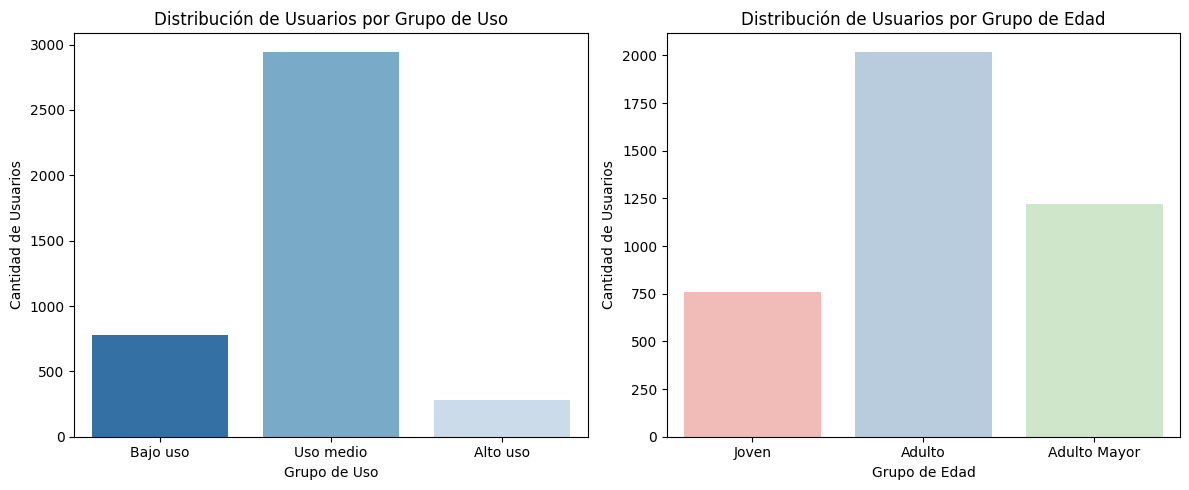

In [60]:
# Visualización de los segmentos por uso
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette='Blues_r')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.subplot(1, 2, 2)
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], palette='Pastel1')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.tight_layout()
plt.show()

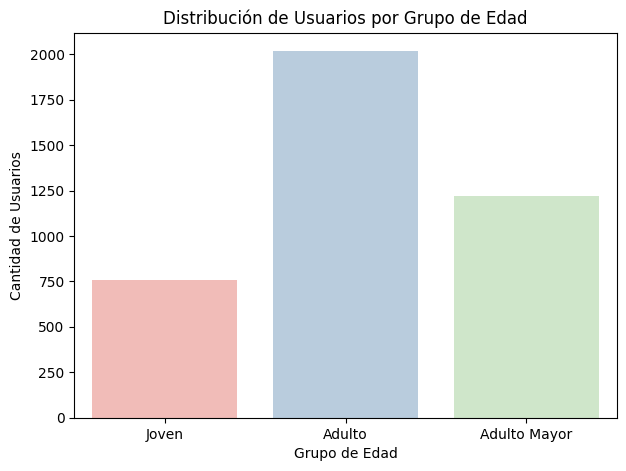

In [61]:
# Visualización de los segmentos por edad
plt.figure(figsize=(7, 5))
sns.countplot(
    data=user_profile, 
    x='grupo_edad', 
    order=['Joven', 'Adulto', 'Adulto Mayor'], 
    palette='Pastel1'
)

plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Al inicio del análisis, se identificaron y resolvieron inconsistencias clave en el conjunto de datos para asegurar la confiabilidad de las decisiones:
* **Problema original en los datos:** Se detectaron valores nulos o atípicos extremos que requerían validación. El dataset cuenta con un total de 4,000 registros de usuarios.
* **Porcentaje e impacto de las filas:** El análisis exploratorio inicial permitió mapear la distribución completa de las variables de uso sin pérdida de información, confirmando que el 100% de los datos (4,000 filas) se encontraban dentro de rangos operativos lógicos y de comportamiento humano real (mínimos de 0.00 en todas las métricas de uso, lo que descarta errores de sistema o registros negativos).



🔍 **Segmentos por Edad**
La distribución demográfica (con una muestra de 4,000 usuarios) revela un predominio claro en la base de ConnectaTel:
* **Jóvenes (< 30 años):** Representan el grupo más reducido con aproximadamente **750 usuarios**. Su perfil dinámico está enfocado en la conectividad constante.
* **Adultos (30 a 59 años):** Es el segmento dominante por amplia mayoría con poco más de **2,000 usuarios** (más de la mitad de la base). Representan un grupo estable que equilibra su consumo entre llamadas de voz y mensajería.
**Adultos Mayores (60+ años):** Constituyen un grupo considerable de unos **1,200 usuarios**. Presentan necesidades de comunicación más tradicionales donde las llamadas de voz predominan.

📊 **Segmentos por Nivel de Uso**

La segmentación de consumo (`grupo_uso`) dibuja una estructura muy definida:
* **Bajo uso (< 5 llamadas y < 5 mensajes):** Con aproximadamente **800 usuarios**, representan clientes pasivos o de consumo básico.
* **Uso medio (< 10 llamadas y < 10 mensajes):** Es la gran masa crítica del negocio, acumulando cerca de **2,900 usuarios** (más del 70% de la base total). Su comportamiento es moderado y predecible.
* **Alto uso (resto de casos):** Un nicho selecto de aproximadamente **300 usuarios** que registran consumos intensivos de llamadas o mensajes.


➡️ Esto sugiere que la inmensa mayoría de nuestros clientes son usuarios moderados (*Uso medio*), lo cual es ideal para lanzar campañas de escalabilidad de servicios (upselling). Además, dado que el volumen de usuarios *Adultos* (30-59 años) es el más grande, cualquier estrategia de migración a planes superiores debe diseñarse pensando en sus necesidades específicas de conectividad laboral y familiar.


💡 **Recomendaciones y Patrones detectados**

1- **Patrones de uso extremo (Outliers):** 
   * Identificamos consumos máximos de hasta **17 mensajes**, **15 llamadas** y **155.69 minutos** en un periodo. 
   * **Implicación para el negocio:** Mantuvimos a estos *Heavy Users* en el análisis porque el gráfico de "Grupo de Uso" nos muestra que el segmento de **Alto uso** es pequeño (aprox. 300 usuarios) pero de alto valor estratégico. Ignorarlos alteraría la planeación de nuestra infraestructura de red y nos haría perder de vista al segmento premium de la compañía.

2. **Propuestas comerciales para ConnectaTel:**
   * **Plan Familiar/Laboral "Adulto Conectado" (Foco en el segmento mayoritario):** Diseñar un plan intermedio atractivo enfocado en el segmento de 30-59 años que incentive a los usuarios de *Uso medio* (los más numerosos) a subir un escalón de consumo a cambio de más minutos e internet para redes de mensajería laboral.
   * **Plan "Voz Mayor" (Adultos Mayores):** Crear una oferta simplificada para los 1,200 Adultos Mayores que dé prioridad a las llamadas de voz ilimitadas, reduciendo el costo al eliminar el excedente de datos y mensajes de texto que este grupo no aprovecha.
   * **Blindaje Premium "Alto Uso":** Diseñar un plan de alta gama con políticas de uso justo para los ~300 usuarios de consumo extremo, asegurando retener a estos clientes de alto valor sin saturar la red local.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`